In [39]:
from cartopy.io.shapereader import Reader
import numpy as np
import cartopy.crs as ccrs 
import cartopy.feature as cf
import matplotlib.pyplot as plt
import cartopy.io.shapereader as shpreader
from cartopy.mpl.ticker import LatitudeFormatter,LongitudeFormatter
import cartopy.feature as cfeature
from matplotlib.path import Path
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpt
from cartopy.mpl.patch import geos_to_path, path_to_geos
from glob import glob
from scipy import stats
from plot_picture_function import set_map_ticks, add_Chinese_provinces, polygon_to_mask
import netCDF4
import xarray as xr
import os 
from glob import glob
import pandas as pd # 加载模块

In [2]:
lon = np.linspace(70.5, 140.5, 71)
lat = np.linspace(55.5, 15.5, 41)

In [3]:
meiyu_startDate = ['20000529', '20010602', '20020610', '20030620', '20040614',
                    '20050626', '20060531','20070610', '20080607', '20090617',
                    '20100617', '20110603', '20120604', '20130606','20140616', 
                    '20150526', '20160525', '20170604', '20180619', '20190616', 
                    '20200601']
meiyu_endDate = ['20000630', '20010628', '20020728', '20030723', '20040721', 
                '20050715', '20060729', '20070727', '20080714', '20090708', 
                '20100726', '20110721', '20120721', '20130709', '20140720',
                '20150727', '20160721', '20170711', '20180710', '20190719', 
                '20200802']

meiyuji_startDate = [f'{i+2000}0601' for i in range(21)]
meiyuji_endDate = [f'{i+2000}0731' for i in range(21)]

days_list = [32, 26, 48, 33, 37, 19, 59, 47, 37, 21, 39, 48, 47, 33, 34, 62, 57, 37, 21, 33, 62]

meiyu_baoy_startDate = ['20030620', '20050626', '20080607', '20100617', '20150526', '20180619', '20200601']
meiyu_baoy_endDate = ['20030723', '20050715', '20080714', '20100726', '20150727', '20180710', '20200802']
baoy_days = [33, 19, 37, 39, 62, 21, 62]

In [4]:
varnamelist = ['INv', 'OTv', 'INh', 'OTh', 'MC', 'ME', 'SE', 'SP', 'GMv', 
                'GMh', 'CWR', 'CEv', 'PEh', 'RCv', 'RCh', 'aveMv', 'aveMh']
varnamelist2 = ['CEv', 'PEh', 'RCv', 'RCh']
def Get_Data(path):
    ds_trans = xr.open_dataset(path)
    filename = os.path.basename(path)
    month = int(filename[18:20])
    print("month:", month)
    # ds_trans = trans_month_result(ds, month)
    datadic = {}#建立空字典
    for varname in varnamelist:
        if varname in varnamelist2:
            datadic[varname] = ds_trans[varname].values
        else:
            datadic[varname] = ds_trans[varname].values / ds_trans['dxy'].values
    return datadic, month

In [5]:
from datetime import datetime, timedelta

def generate_date_strings(start_date, end_date):
    # 将字符串转换为日期对象
    if start_date == end_date:
        return None
    start = datetime.strptime(start_date, '%Y%m%d')
    end = datetime.strptime(end_date, '%Y%m%d')
    
    # 生成日期字符串列表
    date_list = []
    current_date = start
    while current_date <= end:
        date_list.append(current_date.strftime('%Y-%m-%d'))
        current_date += timedelta(days=1)
    
    return date_list

In [ ]:
# H:\邢台观测站\python_qixianglianxi\shp\武汉市\武汉市.shp
# H:\邢台观测站\python_qixianglianxi\shp\安徽省\安徽省.shp
# H:\邢台观测站\python_qixianglianxi\shp\江西省\江西省.shp
# H:\邢台观测站\python_qixianglianxi\shp\淮河流域\淮河流域边界.shp
# reader = Reader(r"H:\邢台观测站\python_qixianglianxi\shp\淮河流域\淮河流域边界.shp")
# geo_list=list(reader.geometries())
# geometry = cfeature.ShapelyFeature(reader.geometries(), ccrs.PlateCarree())

In [ ]:
# import math
# import shapely.geometry as sgeom
# from shapely.prepared import prep
# #74, 134, 20, 53
# lonmin, lonmax = 70.5, 140.5
# latmin, latmax = 15.5, 55.5
# npt = 1
# x = np.linspace(lonmin, lonmax, 71)
# y = np.linspace(latmax, latmin, 41)
# x, y = np.meshgrid(x, y)
# z = np.ones([41, 71])
# mask = polygon_to_mask(geo_list[0], x, y)
# z[~mask] = np.nan

#### 梅雨季

In [19]:
# 示例
# [3, 3, 5, 8, 10, 15, 16, 18, 20, 20, 20]
year_list = [i for i in range(21)]
# year_list = [3, 5, 8, 10, 15, 18, 20]
# year_list = [16]
statistics_values = {}
for i_Y in range(len(year_list)):
    #创建文件列表
    iyear = 2000+year_list[i_Y]
    start_date = meiyuji_startDate[i_Y]  #'20160718'
    end_date = meiyuji_endDate[i_Y]  #'20160720'
    dates = generate_date_strings(start_date, end_date)
    fplist = []
    for _, idate in enumerate(dates):
        fplist.append(glob(fr'H:\NCEP_fixed\{iyear}\p2_as_matlab\ResultGrid_D_{idate}*.nc')[0])
    #创建数据字典
    totaldict = {}
    for i in range(len(fplist)):
        tempdict, _ = Get_Data(fplist[i])
        for vname in varnamelist:
            if vname in totaldict.keys():
                totaldict[vname].append(tempdict[vname])
            else:
                totaldict[vname] = [tempdict[vname]]

    for vname in varnamelist:
        totaldict[vname] = np.array(totaldict[vname])
    #统计数据分析
    
    # mask_bool = mask.astype(bool)
    MMh = totaldict['aveMh'].mean(axis=0)
    Ps_sum = totaldict['SP'].sum(axis=0)
    print(totaldict['SP'].shape)
    RTh_temp = MMh / (Ps_sum / (3 * 24))
    if i_Y == 0:
        RTh = RTh_temp.copy()[np.newaxis,:,:]
    else:
        RTh = np.vstack([RTh, RTh_temp[np.newaxis,:,:]])
    for key in totaldict.keys():
        if i_Y == 0:
            if key in ['CEv', 'PEv', 'PEw', 'PEh', 'RCv', 'RCh']:
                statistics_values[key] = totaldict[key].mean(axis=0)
                statistics_values[key] = statistics_values[key][np.newaxis,:,:]
            else:
                print(key)
                if key in ['aveMv', 'aveMh']:
                    statistics_values[key] = totaldict[key].mean(axis=0)
                    statistics_values[key] = statistics_values[key][np.newaxis,:,:]
                else:
                    statistics_values[key] = totaldict[key].sum(axis=0)
                    statistics_values[key] = statistics_values[key][np.newaxis,:,:]
        else:
            
            if key in ['CEv', 'PEv', 'PEw', 'PEh', 'RCv', 'RCh']:
                statistics_values[key] = np.vstack([statistics_values[key], totaldict[key].mean(axis=0)[np.newaxis,:,:]])
                    
            else:
                if key in ['aveMv', 'aveMh']:
                    statistics_values[key] = np.vstack([statistics_values[key], totaldict[key].mean(axis=0)[np.newaxis,:,:]])
                else:
                    
                    statistics_values[key] = np.vstack([statistics_values[key], totaldict[key].sum(axis=0)[np.newaxis,:,:]])
        


month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
(61, 41, 71)
INv
OTv
INh
OTh
MC
ME
SE
SP
GMv
GMh
CWR
aveMv
aveMh
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 6
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7
month: 7

In [21]:
def plot_var1(ax, varname, plot_data,  maxvalue, minvalue=0, unit='mm', scale=1, plotGeo=False):
    # fig = plt.figure(figsize=(9,6), dpi=100)
    # ax = fig.add_axes([0.01, 0.01, 0.65, 0.75], projection=proj)

    levels = np.linspace(minvalue, maxvalue, 11)
    if varname != 'RTh':
        axc = ax.contourf(lon, lat, plot_data.mean(axis=0)/scale, cmap='YlGnBu', extend='max', levels=levels)#lat轴颠倒 'RdYlBu' 'RdYlBu' 'YlGnBu'
    else:
        axc = ax.contourf(lon, lat, RTh_mean, cmap='YlGnBu', extend='max', levels=levels)
    # line_path = axc.collections[4].get_paths()
    # ax.add_feature(provinces, facecolor='None', edgecolor='k')
    set_map_ticks(ax, dx=3, dy=2, nx=1, ny=1, labelsize='large')
    add_Chinese_provinces(ax, lw=0.5, ec='grey', fc='none')#后两个参数是设置eagecolor,facecolor,linewigth线宽
    ax.set_ylim([28.5, 33.5])
    ax.set_xlim([109.5, 123.5])
    ax.tick_params('both', labelsize=10)
    # ax.set_title('CWR')
    cax1 = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0, 0.02, ax.get_position().height])
    cb = plt.colorbar(axc, cax=cax1)
    cb.ax.set_title(unit, loc='left')
    cb.ax.tick_params('y', labelsize=15)

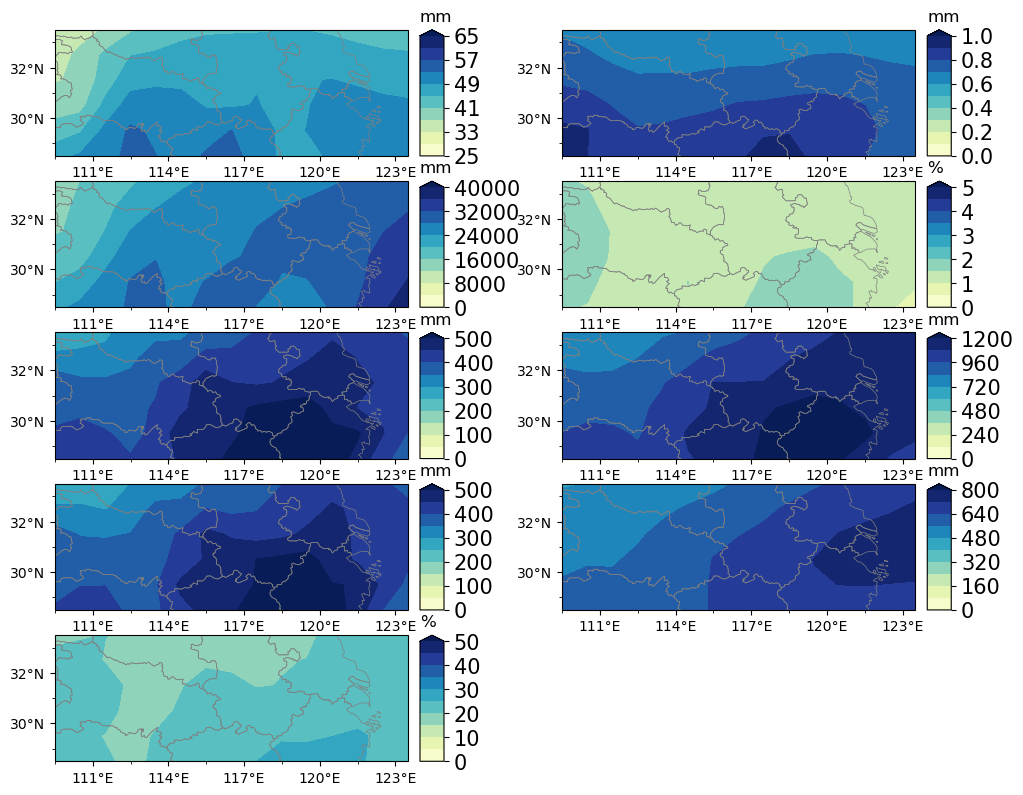

In [34]:
fig = plt.figure(figsize=(12,9.5), dpi=100)
proj = ccrs.PlateCarree()
ax1 = fig.add_subplot(521, projection=proj)
plot_data = statistics_values['aveMv']
plot_var1(ax1, 'aveMv', plot_data, 
          maxvalue=65, minvalue=25,  plotGeo=True)

ax2 = fig.add_subplot(522, projection=proj)
plot_data = statistics_values['aveMh']
plot_var1(ax2, 'aveMh', plot_data, 
          maxvalue=1, minvalue=0,  plotGeo=True)

ax3 = fig.add_subplot(523, projection=proj)
plot_data = statistics_values['GMv']
plot_var1(ax3, 'GMv', plot_data, 
          maxvalue=40000, minvalue=0,  plotGeo=True)

ax4 = fig.add_subplot(524, projection=proj)
plot_data = statistics_values['CEv']
plot_var1(ax4, 'CEv', plot_data, 
          maxvalue=5, minvalue=0,  plotGeo=True, unit='%')

ax5 = fig.add_subplot(525, projection=proj)
plot_data = statistics_values['MC']
plot_var1(ax5, 'Cvh', plot_data, 
          maxvalue=500, minvalue=0,  plotGeo=True)

ax6 = fig.add_subplot(526, projection=proj)
plot_data = statistics_values['GMh']
plot_var1(ax6, 'GMh', plot_data, 
          maxvalue=1200, minvalue=0,  plotGeo=True)

ax7 = fig.add_subplot(527, projection=proj)
plot_data = statistics_values['SP']
plot_var1(ax7, 'Ps', plot_data, 
          maxvalue=500, minvalue=0,  plotGeo=True)

ax7 = fig.add_subplot(528, projection=proj)
plot_data = statistics_values['CWR']
plot_var1(ax7, 'CWR', plot_data, 
          maxvalue=800, minvalue=0,  plotGeo=True)

ax8 = fig.add_subplot(529, projection=proj)
plot_data = statistics_values['PEh']
plot_var1(ax8, 'PEh', plot_data, 
          maxvalue=50, minvalue=0,  plotGeo=True, unit='%')

In [29]:
# df.to_csv(r'D:\我的业务\MeiYu\result_output_meiyu_China_rangle.csv', index=False, float_format='%.3f')

In [ ]:
# 湖北 2016/07/18 - 2016/07/20

#### 梅雨时期

In [ ]:
# 示例
# [3, 3, 5, 8, 10, 15, 16, 18, 20, 20, 20]
year_list = [i for i in range(21)]
# year_list = [3, 5, 8, 10, 15, 18, 20]
# year_list = [16]
statistics_values = {}
for i_Y in range(len(year_list)):
    #创建文件列表
    iyear = 2000+year_list[i_Y]
    start_date = meiyu_startDate[i_Y]  #'20160718'
    end_date = meiyu_endDate[i_Y]  #'20160720'
    dates = generate_date_strings(start_date, end_date)
    fplist = []
    for _, idate in enumerate(dates):
        fplist.append(glob(fr'H:\NCEP_fixed\{iyear}\p2_as_matlab\ResultGrid_D_{idate}*.nc')[0])
    #创建数据字典
    totaldict = {}
    for i in range(len(fplist)):
        tempdict, _ = Get_Data(fplist[i])
        for vname in varnamelist:
            if vname in totaldict.keys():
                totaldict[vname].append(tempdict[vname])
            else:
                totaldict[vname] = [tempdict[vname]]

    for vname in varnamelist:
        totaldict[vname] = np.array(totaldict[vname])
    #统计数据分析
    
    # mask_bool = mask.astype(bool)
    MMh = totaldict['aveMh'].mean(axis=0)
    Ps_sum = totaldict['SP'].sum(axis=0)
    print(totaldict['SP'].shape)
    RTh_temp = MMh / (Ps_sum / (days_list[i_Y] * 24))
    if i_Y == 0:
        RTh = RTh_temp.copy()[np.newaxis,:,:]
    else:
        RTh = np.vstack([RTh, RTh_temp[np.newaxis,:,:]])
    for key in totaldict.keys():
        if i_Y == 0:
            if key in ['CEv', 'PEv', 'PEw', 'PEh', 'RCv', 'RCh']:
                statistics_values[key] = totaldict[key].mean(axis=0)
                statistics_values[key] = statistics_values[key][np.newaxis,:,:]
            else:
                print(key)
                if key in ['aveMv', 'aveMh']:
                    statistics_values[key] = totaldict[key].mean(axis=0)
                    statistics_values[key] = statistics_values[key][np.newaxis,:,:]
                else:
                    statistics_values[key] = totaldict[key].sum(axis=0)
                    statistics_values[key] = statistics_values[key][np.newaxis,:,:]
        else:
            
            if key in ['CEv', 'PEv', 'PEw', 'PEh', 'RCv', 'RCh']:
                statistics_values[key] = np.vstack([statistics_values[key], totaldict[key].mean(axis=0)[np.newaxis,:,:]])
                    
            else:
                if key in ['aveMv', 'aveMh']:
                    statistics_values[key] = np.vstack([statistics_values[key], totaldict[key].mean(axis=0)[np.newaxis,:,:]])
                else:
                    
                    statistics_values[key] = np.vstack([statistics_values[key], totaldict[key].sum(axis=0)[np.newaxis,:,:]])


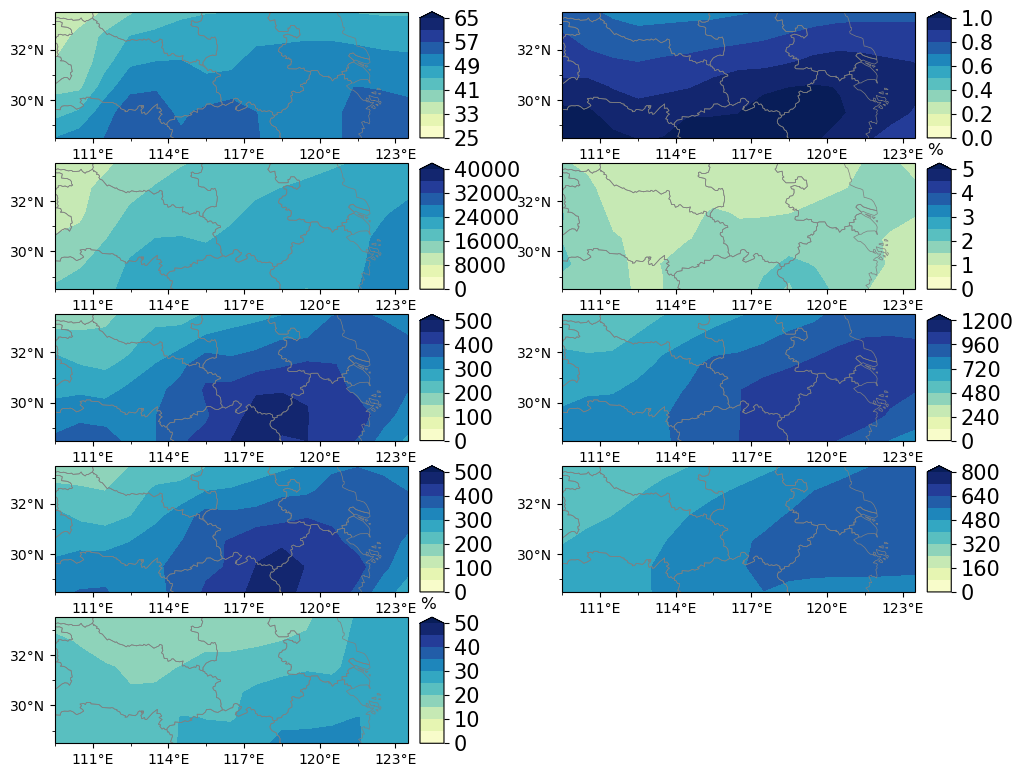

In [41]:
# 创建图形
fig = plt.figure(figsize=(12, 9.5), dpi=100)

# 定义 5 行 2 列的网格
gs = GridSpec(5, 2, figure=fig)

# 统一的投影对象（可复用）
proj = ccrs.PlateCarree()

# 配置列表：(GridSpec索引, 数据键, 绘图标题, 最大值, 最小值, 单位)
# 对应原 521~529 共 9 个子图
configs = [
    (0, 'aveMv', 'aveMv', 65, 25, None),   # 原 521
    (1, 'aveMh', 'aveMh', 1, 0, None),     # 原 522
    (2, 'GMv', 'GMv', 40000, 0, None),     # 原 523
    (3, 'CEv', 'CEv', 5, 0, '%'),          # 原 524
    (4, 'MC', 'Cvh', 500, 0, None),        # 原 525 (注意title为'Cvh')
    (5, 'GMh', 'GMh', 1200, 0, None),      # 原 526
    (6, 'SP', 'Ps', 500, 0, None),         # 原 527 (注意title为'Ps')
    (7, 'CWR', 'CWR', 800, 0, None),       # 原 528
    (8, 'PEh', 'PEh', 50, 0, '%'),         # 原 529
]

# 循环绘制 9 个子图
for idx, (gs_idx, key, title, maxval, minval, unit) in enumerate(configs):
    # 通过 gs[gs_idx] 定位到网格位置（0~8 对应 521~529）
    ax = fig.add_subplot(gs[gs_idx], projection=proj)
    plot_data = statistics_values[key]
    plot_var1(ax, title, plot_data,
              maxvalue=maxval, minvalue=minval,
              plotGeo=True,
              unit=unit if unit else '')   # 避免 unit=None 时显示为 'None'

# 第 10 个位置（原 5210，即第5行第2列）没有使用，无需创建任何轴
# 若想保留空白占位，可显式添加并隐藏：
# fig.add_subplot(gs[9]).set_visible(False)

# 自动调整子图间距
# plt.tight_layout()
plt.show()

#### 暴雨结果

In [ ]:
# 示例
# [3, 3, 5, 8, 10, 15, 16, 18, 20, 20, 20]
year_list = [i for i in range(21)]
# year_list = [3, 5, 8, 10, 15, 18, 20]
# year_list = [16]
statistics_values = {}
for i_Y in range(len(year_list)):
    #创建文件列表
    iyear = 2000+year_list[i_Y]
    start_date = meiyu_startDate[i_Y]  #'20160718'
    end_date = meiyu_endDate[i_Y]  #'20160720'
    dates = generate_date_strings(start_date, end_date)
    fplist = []
    for _, idate in enumerate(dates):
        fplist.append(glob(fr'H:\NCEP_fixed\{iyear}\p2_as_matlab\ResultGrid_D_{idate}*.nc')[0])
    #创建数据字典
    totaldict = {}
    for i in range(len(fplist)):
        tempdict, _ = Get_Data(fplist[i])
        for vname in varnamelist:
            if vname in totaldict.keys():
                totaldict[vname].append(tempdict[vname])
            else:
                totaldict[vname] = [tempdict[vname]]

    for vname in varnamelist:
        totaldict[vname] = np.array(totaldict[vname])
    #统计数据分析
    
    # mask_bool = mask.astype(bool)
    MMh = totaldict['aveMh'].mean(axis=0)
    Ps_sum = totaldict['SP'].sum(axis=0)
    print(totaldict['SP'].shape)
    RTh_temp = MMh / (Ps_sum / (days_list[i_Y] * 24))
    if i_Y == 0:
        RTh = RTh_temp.copy()[np.newaxis,:,:]
    else:
        RTh = np.vstack([RTh, RTh_temp[np.newaxis,:,:]])
    for key in totaldict.keys():
        if i_Y == 0:
            if key in ['CEv', 'PEv', 'PEw', 'PEh', 'RCv', 'RCh']:
                statistics_values[key] = totaldict[key].mean(axis=0)
                statistics_values[key] = statistics_values[key][np.newaxis,:,:]
            else:
                print(key)
                if key in ['aveMv', 'aveMh']:
                    statistics_values[key] = totaldict[key].mean(axis=0)
                    statistics_values[key] = statistics_values[key][np.newaxis,:,:]
                else:
                    statistics_values[key] = totaldict[key].sum(axis=0)
                    statistics_values[key] = statistics_values[key][np.newaxis,:,:]
        else:
            
            if key in ['CEv', 'PEv', 'PEw', 'PEh', 'RCv', 'RCh']:
                statistics_values[key] = np.vstack([statistics_values[key], totaldict[key].mean(axis=0)[np.newaxis,:,:]])
                    
            else:
                if key in ['aveMv', 'aveMh']:
                    statistics_values[key] = np.vstack([statistics_values[key], totaldict[key].mean(axis=0)[np.newaxis,:,:]])
                else:
                    
                    statistics_values[key] = np.vstack([statistics_values[key], totaldict[key].sum(axis=0)[np.newaxis,:,:]])
